In [1]:
import numpy as np
from numpy.linalg import inv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.datasets import make_spd_matrix
from sklearn.covariance import graphical_lasso, GraphicalLasso, GraphicalLassoCV
from tqdm.notebook import tqdm

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch
from scipy.stats import chi2

from numpy.lib.stride_tricks import sliding_window_view

from statsmodels.stats.multitest import fdrcorrection

%matplotlib inline

# fix random seed
np.random.seed(39)

In [6]:
fred_md = pd.read_csv("https://files.stlouisfed.org/files/htdocs/fred-md/monthly/current.csv", skiprows=[1])
fred_md.head()

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,1/1/1959,2442.158,2293.2,17.272,292266.4261,18235.77392,22.0733,23.4027,22.2858,31.5688,...,17.791,11.326,2.13,2.45,2.04,NaN,6476.0,12298.0,84.2043,NaN
1,2/1/1959,2451.778,2301.5,17.452,294424.7425,18369.56308,22.5056,23.7185,22.4788,31.8004,...,17.798,11.343,2.14,2.46,2.05,NaN,6476.0,12298.0,83.5280,NaN
2,3/1/1959,2467.594,2318.5,17.617,293418.6704,18523.05762,22.8298,23.8621,22.5892,31.8004,...,17.785,11.363,2.15,2.45,2.07,NaN,6508.0,12349.0,81.6405,NaN
3,4/1/1959,2483.671,2334.9,17.553,299322.8039,18534.46600,23.3161,24.2067,22.9201,32.3021,...,17.796,11.403,2.16,2.47,2.08,NaN,6620.0,12484.0,81.8099,NaN
4,5/1/1959,2498.026,2350.4,17.765,301364.3249,18679.66354,23.6673,24.4077,23.1408,32.4565,...,17.777,11.421,2.17,2.48,2.08,95.3,6753.0,12646.0,80.7315,NaN


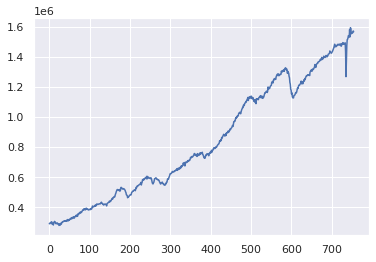

In [11]:
plt.plot(fred_md.iloc[:, 4])